## Import libraries & set random seed

In [ ]:
import numpy as np
import pandas as pd
import os
import random
import warnings
import cv2
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import inception_v3, Inception_V3_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm

warnings.filterwarnings('ignore')

manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


## Load & Filter Data

In [ ]:
meta_dir = "/kaggle/input/isic-2024-challenge/"
df = pd.read_csv(meta_dir + "train-metadata.csv")
df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [ ]:
df_filtered = df[df["target"] == 1].reset_index(drop=True)
df_filtered.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0082829,1,IP_3249371,80.0,female,anterior torso,9.27,TBP tile: close-up,3D: XP,18.093368,...,IL_7881385,Malignant::Malignant epidermal proliferations:...,Malignant,Malignant epidermal proliferations,Squamous cell carcinoma in situ,NaN,NaN,NaN,NaN,72.211683
1,ISIC_0096034,1,IP_6723298,75.0,male,head/neck,3.88,TBP tile: close-up,3D: white,26.187010,...,IL_5240575,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular",NaN,NaN,NaN,94.559590
2,ISIC_0104229,1,IP_9057861,80.0,male,anterior torso,6.55,TBP tile: close-up,3D: white,33.480140,...,IL_1702337,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular",NaN,NaN,NaN,66.196170
3,ISIC_0119495,1,IP_6856511,60.0,male,upper extremity,5.27,TBP tile: close-up,3D: white,25.872050,...,IL_3266850,Malignant::Malignant epidermal proliferations:...,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,NaN,NaN,NaN,99.991270
4,ISIC_0157834,1,IP_3927284,55.0,male,posterior torso,5.29,TBP tile: close-up,3D: white,30.966662,...,IL_2429082,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Superficial",NaN,NaN,NaN,99.960846


In [ ]:
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
save_dir = '/kaggle/working/clahe_final'
os.makedirs(save_dir, exist_ok=True)

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

## Hair Removal Function

In [ ]:
def remove_hairs_dullrazor(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)
    return inpainted

## CLAHE Function

In [ ]:
def apply_clahe_yuv(img):
    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    y_channel = yuv[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    yuv[:, :, 0] = clahe.apply(y_channel)
    return cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

## Augmentation Function

In [ ]:
def augment_image(img):
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))
    return aug_imgs

## Visualize with the malignant skin cancer cells

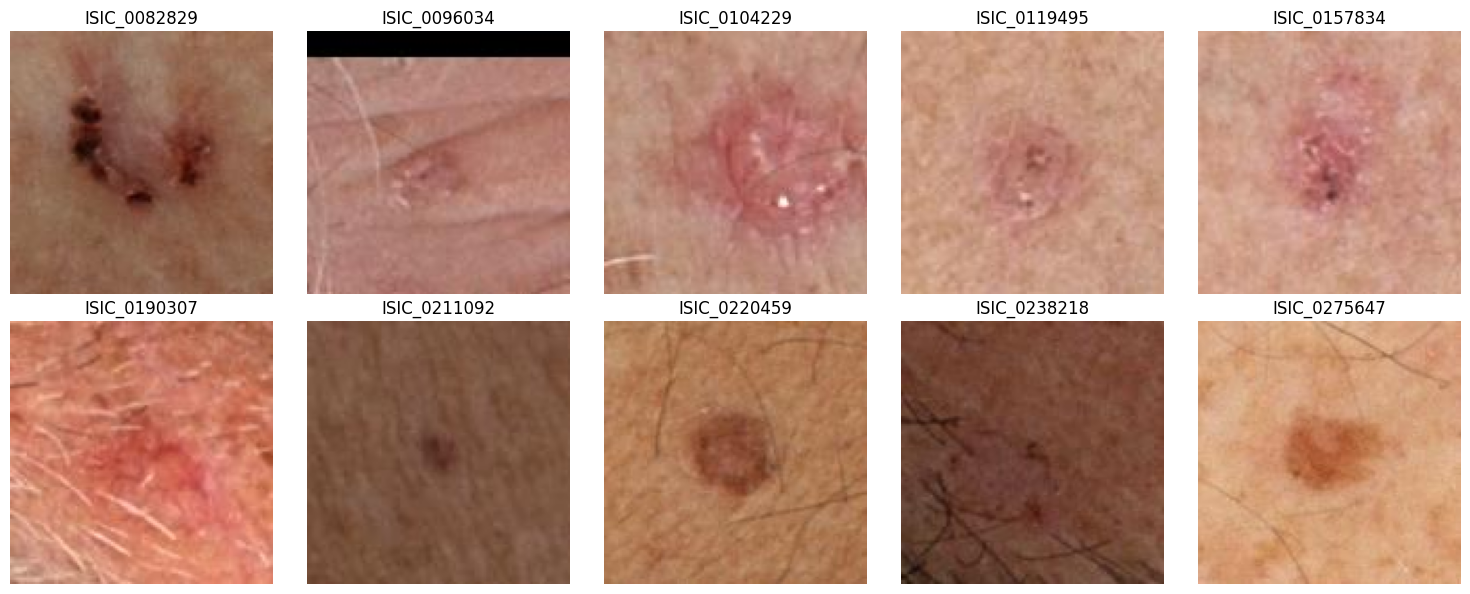

In [ ]:
isic_ids = df_filtered['isic_id'].head(10)

plt.figure(figsize=(15, 6))
for i, isic_id in enumerate(isic_ids):
    image_path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = Image.open(image_path).convert("RGB")
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Apply yuv clahe preprocessing technique

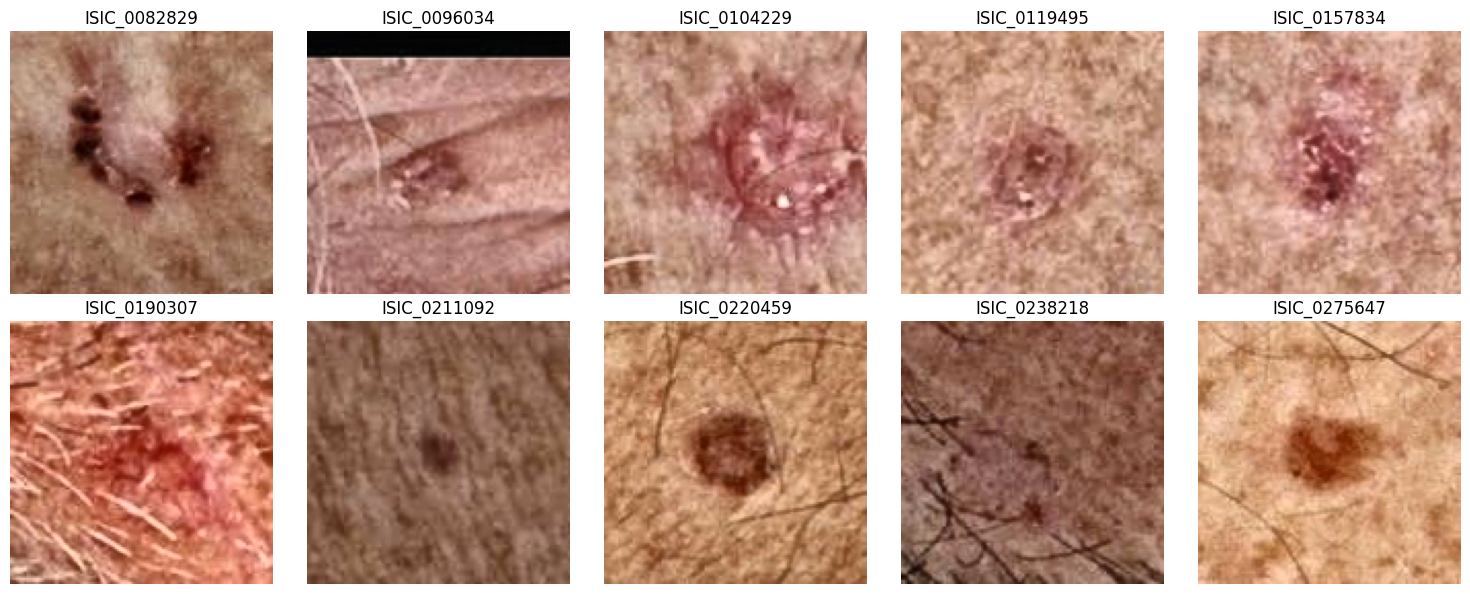

In [ ]:
save_dir_yuv = '/kaggle/working/clahe_images'
os.makedirs(save_dir_yuv, exist_ok=True)

isic_ids = df_filtered['isic_id'].head(10)
plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    y_channel = yuv[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    yuv[:, :, 0] = clahe.apply(y_channel)
    clahe_img = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    save_path = os.path.join(save_dir_yuv, f"{isic_id}_clahe.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(clahe_img, cv2.COLOR_RGB2BGR))

    plt.subplot(2, 5, i + 1)
    plt.imshow(clahe_img)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Apply LAB clahe preprocessing technique

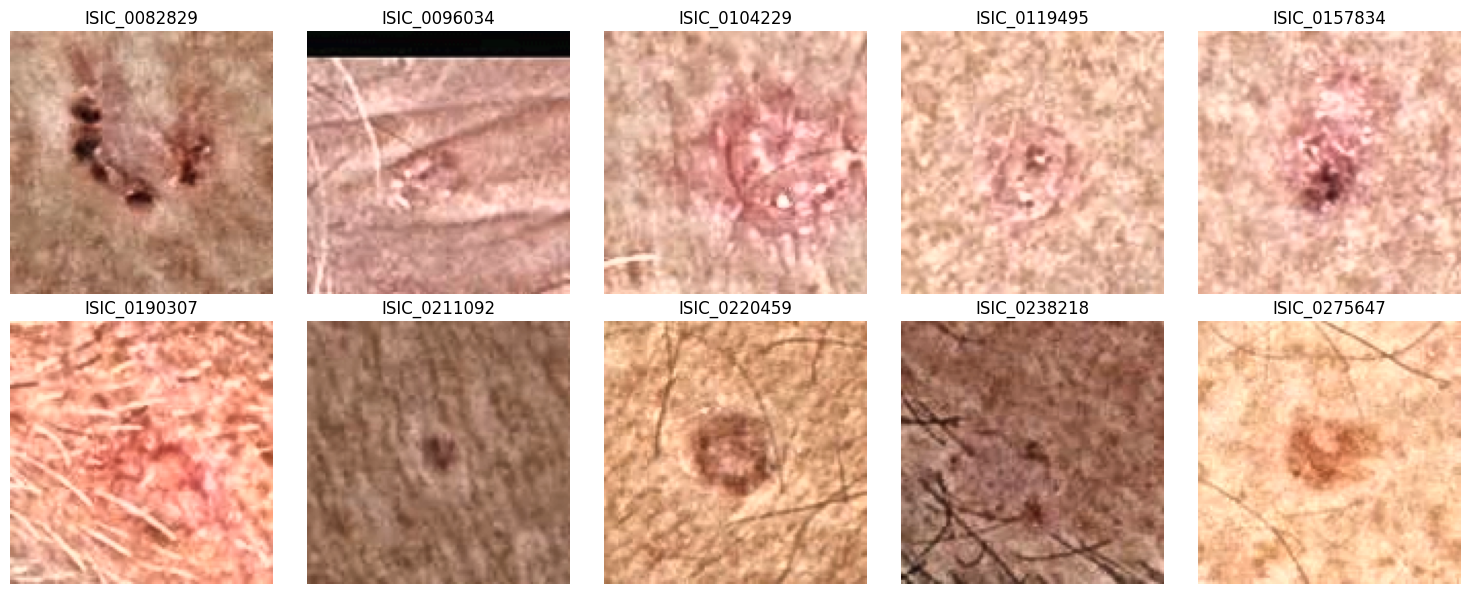

In [ ]:
save_dir_lab_exp = '/kaggle/working/clahe_images_lab_preview'
os.makedirs(save_dir_lab_exp, exist_ok=True)

isic_ids = df_filtered['isic_id'].head(10)
plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_Lab2RGB)

    save_path = os.path.join(save_dir_lab_exp, f"{isic_id}_clahe.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(img_clahe, cv2.COLOR_RGB2BGR))

    plt.subplot(2, 5, i + 1)
    plt.imshow(img_clahe)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## CLAHE yuv and augmetation functions

In [ ]:
def apply_clahe_yuv(img):
    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    y_channel = yuv[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    yuv[:, :, 0] = clahe.apply(y_channel)
    return cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

def augment_image(img):
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))
    return aug_imgs

## Experiment with different Preprocessing techniques 

In [ ]:
image_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
save_dir = '/kaggle/working/clahe_images_lab'
os.makedirs(save_dir, exist_ok=True)
malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)
new_records = []
for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    img_path = os.path.join(image_dir, f"{isic_id}.jpg")
    save_path = os.path.join(save_dir, f"{isic_id}.jpg")
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to read: {img_path}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = remove_hairs_dullrazor(img)
    img = apply_clahe_yuv(img)
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    new_records.append({'isic_id': isic_id, 'target': label})
    if label == 1:
        aug_imgs = augment_image(img)
        for i, aug_img in enumerate(aug_imgs):
            aug_id = f"{isic_id}_aug{i}"
            aug_path = os.path.join(save_dir, f"{aug_id}.jpg")
            cv2.imwrite(aug_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
            new_records.append({'isic_id': aug_id, 'target': 1})
df_filtered = pd.DataFrame(new_records).reset_index(drop=True)
print(f"Final dataset size: {len(df_filtered)}")
df_filtered.head()

100%|██████████| 10393/10393 [01:32<00:00, 112.76it/s]

Final dataset size: 12751


,isic_id,target
0,ISIC_0082829,1
1,ISIC_0082829_aug0,1
2,ISIC_0082829_aug1,1
3,ISIC_0082829_aug2,1
4,ISIC_0082829_aug3,1


## Define Dataset Class

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_df, val_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered["target"], random_state=42)

train_dataset = SkinLesionDataset(train_df, save_dir, transform)
val_dataset = SkinLesionDataset(val_df, save_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## Inception v3 Binary Classifier model

In [ ]:
class InceptionV3BinaryClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = Inception_V3_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = inception_v3(weights=weights, aux_logits=False)
        
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_feats, 1)
        )

    def forward(self, x):
        return self.backbone(x)

## Before preprocessing and After preprocessing Skin cancer cells visualization

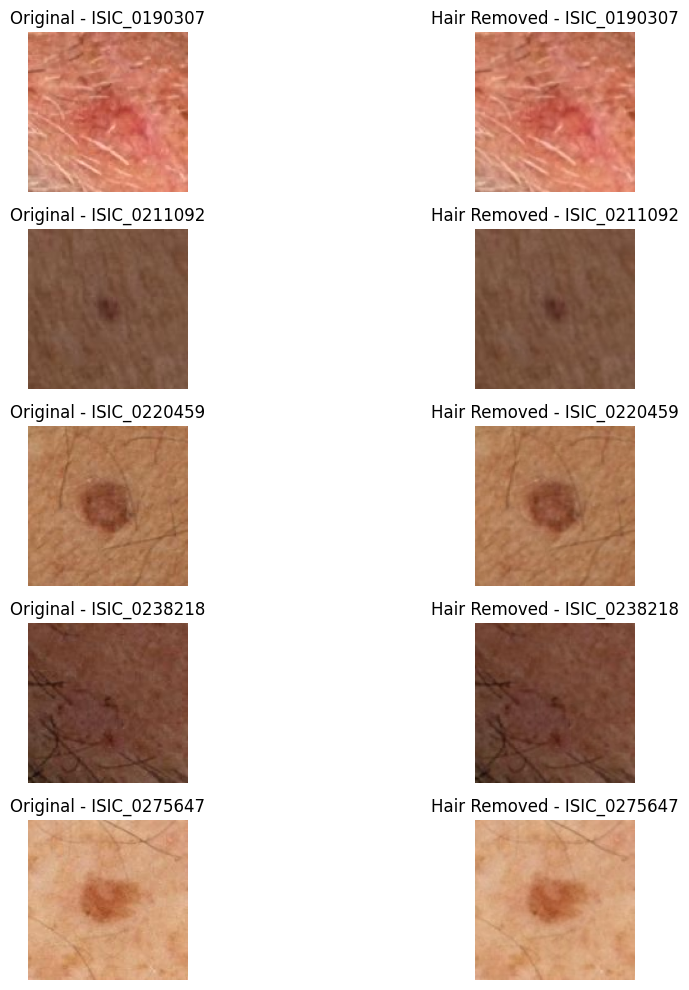

In [ ]:
def show_before_after(isic_ids, original_dir, processed_dir):
    plt.figure(figsize=(12, 10))
    for i, isic_id in enumerate(isic_ids):
        orig_path = os.path.join(original_dir, f"{isic_id}.jpg")
        orig_img = cv2.imread(orig_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

        proc_path = os.path.join(processed_dir, f"{isic_id}.jpg")
        proc_img = cv2.imread(proc_path)
        proc_img = cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(isic_ids), 2, 2 * i + 1)
        plt.imshow(orig_img)
        plt.title(f"Original - {isic_id}")
        plt.axis("off")

        plt.subplot(len(isic_ids), 2, 2 * i + 2)
        plt.imshow(proc_img)
        plt.title(f"Hair Removed - {isic_id}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

sample_ids = df_filtered[df_filtered["isic_id"].str.contains("aug") == False]["isic_id"].iloc[5:10].tolist()

original_dir = '/kaggle/input/isic-2024-challenge/train-image/image'
processed_dir = '/kaggle/working/without_any'

show_before_after(sample_ids, original_dir, processed_dir)

## Model, Optimizer & Scheduler Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = InceptionV3BinaryClassifier(pretrained=True).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.8)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 205MB/s] 


## Full training loop - run epochs using DullRazor + YUV CLAHE preprocessing

In [ ]:
for epoch in range(10):
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        train_preds.extend(preds.flatten())
        train_labels.extend(labels.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            val_loss += loss.item() * imgs.size(0)

            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            val_preds.extend(preds.flatten())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}, Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

Epoch 1: Train Loss = 0.3158, Train Acc = 0.8675, Val Loss = 0.1970, Val Acc = 0.9157
Epoch 2: Train Loss = 0.1303, Train Acc = 0.9523, Val Loss = 0.1801, Val Acc = 0.9224
Epoch 3: Train Loss = 0.0688, Train Acc = 0.9751, Val Loss = 0.1786, Val Acc = 0.9251
Epoch 4: Train Loss = 0.0391, Train Acc = 0.9874, Val Loss = 0.1539, Val Acc = 0.9475
Epoch 5: Train Loss = 0.0334, Train Acc = 0.9877, Val Loss = 0.1296, Val Acc = 0.9557
Epoch 6: Train Loss = 0.0290, Train Acc = 0.9900, Val Loss = 0.1291, Val Acc = 0.9581
Epoch 7: Train Loss = 0.0342, Train Acc = 0.9885, Val Loss = 0.1089, Val Acc = 0.9569
Epoch 8: Train Loss = 0.0192, Train Acc = 0.9931, Val Loss = 0.2013, Val Acc = 0.9408
Epoch 9: Train Loss = 0.0154, Train Acc = 0.9948, Val Loss = 0.1247, Val Acc = 0.9628
Epoch 10: Train Loss = 0.0153, Train Acc = 0.9954, Val Loss = 0.1321, Val Acc = 0.9600


## Train using Hair removal preprocessing Techniques

Epoch 1: Train Loss = 0.4100, Train Acc = 0.8288, Val Loss = 0.3499, Val Acc = 0.8648

Epoch 2: Train Loss = 0.3448, Train Acc = 0.8594, Val Loss = 0.3097, Val Acc = 0.8753

Epoch 3: Train Loss = 0.3385, Train Acc = 0.8654, Val Loss = 0.3027, Val Acc = 0.8851

Epoch 4: Train Loss = 0.3320, Train Acc = 0.8671, Val Loss = 0.3041, Val Acc = 0.8753

Epoch 5: Train Loss = 0.3178, Train Acc = 0.8720, Val Loss = 0.2887, Val Acc = 0.8828

Epoch 6: Train Loss = 0.4042, Train Acc = 0.8247, Val Loss = 0.2591, Val Acc = 0.8965

Epoch 7: Train Loss = 0.2177, Train Acc = 0.9122, Val Loss = 0.1809, Val Acc = 0.9314

Epoch 8: Train Loss = 0.1382, Train Acc = 0.9512, Val Loss = 0.1577, Val Acc = 0.9353

Epoch 9: Train Loss = 0.0898, Train Acc = 0.9716, Val Loss = 0.1297, Val Acc = 0.9483

Epoch 10: Train Loss = 0.0615, Train Acc = 0.9820, Val Loss = 0.1226, Val Acc = 0.9526

## Train using only clahe preprocessing Techniques

Epoch 1: Train Loss = 0.0724, Train Acc = 0.9749, Val Loss = 0.0944, Val Acc = 0.9651

Epoch 2: Train Loss = 0.0611, Train Acc = 0.9791, Val Loss = 0.0722, Val Acc = 0.9726

Epoch 3: Train Loss = 0.0545, Train Acc = 0.9816, Val Loss = 0.0727, Val Acc = 0.9757

Epoch 4: Train Loss = 0.0461, Train Acc = 0.9840, Val Loss = 0.0875, Val Acc = 0.9726

Epoch 5: Train Loss = 0.0532, Train Acc = 0.9817, Val Loss = 0.0705, Val Acc = 0.9753

Epoch 6: Train Loss = 0.0448, Train Acc = 0.9855, Val Loss = 0.0754, Val Acc = 0.9741

Epoch 7: Train Loss = 0.0398, Train Acc = 0.9855, Val Loss = 0.0763, Val Acc = 0.9757

Epoch 8: Train Loss = 0.0340, Train Acc = 0.9881, Val Loss = 0.0717, Val Acc = 0.9757

Epoch 9: Train Loss = 0.0312, Train Acc = 0.9886, Val Loss = 0.0568, Val Acc = 0.9800

Epoch 10: Train Loss = 0.0342, Train Acc = 0.9880, Val Loss = 0.0731, Val Acc = 0.9765 

## Train using only hair removal preprocessing technique 

Epoch 1: Train Loss = 0.1233, Train Acc = 0.9539, Val Loss = 0.1239, Val Acc = 0.9526

Epoch 2: Train Loss = 0.0211, Train Acc = 0.9937, Val Loss = 0.1285, Val Acc = 0.9557

Epoch 3: Train Loss = 0.0067, Train Acc = 0.9988, Val Loss = 0.1093, Val Acc = 0.9667

Epoch 4: Train Loss = 0.0065, Train Acc = 0.9977, Val Loss = 0.1481, Val Acc = 0.9588

Epoch 5: Train Loss = 0.0059, Train Acc = 0.9981, Val Loss = 0.1480, Val Acc = 0.9573

Epoch 6: Train Loss = 0.0056, Train Acc = 0.9983, Val Loss = 0.1570, Val Acc = 0.9604

Epoch 7: Train Loss = 0.0071, Train Acc = 0.9982, Val Loss = 0.1757, Val Acc = 0.9545

Epoch 8: Train Loss = 0.0154, Train Acc = 0.9941, Val Loss = 0.1990, Val Acc = 0.9463

Epoch 9: Train Loss = 0.0194, Train Acc = 0.9936, Val Loss = 0.1555, Val Acc = 0.9565

Epoch 10: Train Loss = 0.0074, Train Acc = 0.9979, Val Loss = 0.1808, Val Acc = 0.9557